# Clase 1 — Regresión Lineal

### ¿Cómo hace una máquina para "aprender" una recta?

En esta clase vamos a entender cómo funciona uno de los algoritmos más simples e importantes del Machine Learning: la **regresión lineal**.

Vamos a trabajar con un caso muy típico: **predecir el precio de venta de una casa a partir de sus metros cuadrados**.

La idea del día:

1. Vamos a mirar un conjunto de datos reales de casas (metros cuadrados y precio).
2. **Ustedes** van a jugar a ser la máquina: van a elegir a mano una recta que prediga el precio lo mejor posible.
3. Vamos a medir qué tan buena fue esa recta con un número (el error).
4. Por último, vamos a ver cómo una computadora encuentra la mejor recta posible automáticamente, en menos de un segundo, usando la librería `scikit-learn`.

Al terminar la clase van a entender qué significa "entrenar un modelo", y por qué eso no es magia: es matemática buscando minimizar un error.

## 0. Preparativos

Corran la siguiente celda para importar las librerías que vamos a usar. Si `ipywidgets` no está instalado, va a instalarlo automáticamente.

In [1]:
import sys
import subprocess

try:
    import ipywidgets
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "ipywidgets"])

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

print("Listo. Ya podemos empezar.")

Listo. Ya podemos empezar.


## 1. ¿Qué es una regresión lineal?

Imaginemos que tenemos un montón de puntos en un gráfico, y sospechamos que, aunque no estén perfectamente alineados, "por detrás" hay una tendencia en forma de recta.

Una recta se describe con dos números:

$$ y = w \cdot x + b $$

- **$w$** es la **pendiente**: cuánto sube (o baja) $y$ por cada unidad que aumenta $x$.
- **$b$** es la **ordenada al origen**: el valor de $y$ cuando $x = 0$ (dónde la recta cruza el eje vertical).

"Hacer una regresión lineal" significa **encontrar los valores de $w$ y $b$** que hacen que esa recta pase lo más cerca posible de todos los puntos.

En nuestro caso: $x$ van a ser los **metros cuadrados** de una casa, e $y$ va a ser su **precio de venta**. $w$ va a representar "cuántos dólares vale cada m2 extra", y $b$ un costo base (terreno, gastos fijos, etc.).

Eso es literalmente lo que hace un modelo de Machine Learning cuando lo "entrenamos": prueba (de forma inteligente) distintos valores de $w$ y $b$ hasta encontrar los mejores.

## 2. Cargamos los datos

Primero, debemos importar los datos de nuestro problema. Utilizaremos el formato .csv

In [10]:
df = pd.read_csv("datos_casas.csv")

m2 = df["m2"].values
precio = df["precio"].values

print(f"Cargamos {len(df)} casas.")
df.head()

Cargamos 60 casas.


,m2,precio
0,36.6,26300.0
1,44.4,76700.0
2,48.7,86200.0
3,55.2,85500.0
4,59.6,88900.0


## 3. Visualizamos los datos

Este es el gráfico con el que vamos a trabajar toda la clase. Mírenlo bien: ¿se imaginan más o menos por dónde pasaría una recta que represente la tendencia de estos puntos?

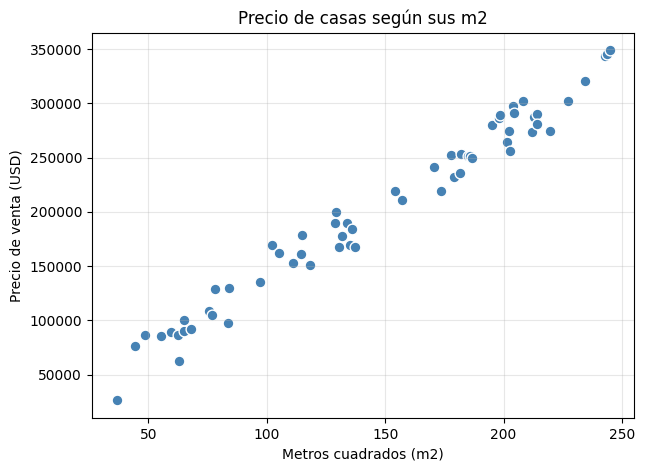

In [11]:
plt.figure(figsize=(7, 5))
plt.scatter(m2, precio, color="steelblue", edgecolor="white", s=60)
plt.xlabel("Metros cuadrados (m2)")
plt.ylabel("Precio de venta (USD)")
plt.title("Precio de casas según sus m2")
plt.grid(alpha=0.3)
plt.show()

## 4. Jueguito: ¡Sean ustedes la máquina!

Abajo hay dos controles deslizantes (*sliders*):

- **pendiente ($w$)**: cuántos dólares vale cada m2 extra.
- **ordenada al origen ($b$)**: el costo base de una casa de 0 m2 (terreno, gastos fijos).

Cada vez que muevan un slider, la recta se va a redibujar sobre los puntos, y abajo del gráfico va a aparecer el error.

### ¿Cómo medimos el error?

Para cada casa, medimos la distancia entre el precio real y el precio que predice la recta que ustedes eligieron. Elevamos esa distancia al cuadrado (para que no importe si la resta dió positivo o negativo) y promediamos entre todas las casas. Eso se llama **Error Cuadrático Medio** (*Mean Squared Error*, o MSE):

$$ \text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (\text{precio}_i - (w \cdot m2_i + b))^2 $$

El problema es que el MSE queda medido en "dólares al cuadrado", que es raro de interpretar. Por eso también vamos a mostrar su raíz cuadrada, el **RMSE**, que sí se mide en dólares: *"en promedio, nos equivocamos por esta cantidad de dólares"*.

**Cuanto más chico es el error, mejor se ajusta la recta a los datos.** El objetivo del juego es: **muevan los sliders y traten de conseguir el RMSE más bajo posible.**

Anoten en algún lado los $w$ y $b$ que encontraron, y el error que lograron. ¡Después vamos a comparar con lo que encuentra la computadora!

In [12]:
def error_cuadratico_medio(precio_real, precio_predicho):
    return np.mean((precio_real - precio_predicho) ** 2)


def graficar_recta(pendiente, ordenada):
    precio_pred = pendiente * m2 + ordenada
    mse = error_cuadratico_medio(precio, precio_pred)
    rmse = np.sqrt(mse)

    plt.figure(figsize=(7, 5))
    plt.scatter(m2, precio, color="steelblue", edgecolor="white", s=60, label="casas reales", zorder=2)

    m2_linea = np.array([m2.min(), m2.max()])
    precio_linea = pendiente * m2_linea + ordenada
    plt.plot(m2_linea, precio_linea, color="crimson", linewidth=2.5, label="tu recta", zorder=3)

    # Líneas punteadas que muestran el error de cada casa
    for m2i, precioi, predi in zip(m2, precio, precio_pred):
        plt.plot([m2i, m2i], [precioi, predi], color="gray", linewidth=0.8, alpha=0.6, zorder=1)

    plt.xlabel("Metros cuadrados (m2)")
    plt.ylabel("Precio de venta (USD)")
    plt.title(f"precio = {pendiente:.0f} · m2 + {ordenada:.0f}")
    plt.legend(loc="upper left")
    plt.grid(alpha=0.3)
    plt.show()

    print(f"Pendiente (w): {pendiente:.0f} USD por m2")
    print(f"Ordenada al origen (b): {ordenada:.0f} USD")
    print(f"RMSE: ${rmse:,.0f}   <-- ¡Traten de bajar este número!")


interact(
    graficar_recta,
    pendiente=FloatSlider(value=0, min=0, max=3000, step=25, description="pendiente (w)"),
    ordenada=FloatSlider(value=0, min=-20000, max=60000, step=1000, description="ordenada (b)"),
);

interactive(children=(FloatSlider(value=0.0, description='pendiente (w)', max=3000.0, step=25.0), FloatSlider(…

Pueden ver que los errores son las lineas grises! Cada línea representa que tan lejos está mi recta de cada punto. La suma de todas las lineas grises, con algunas cositas más, es el RMSE.

## 5. Ahora lo hace la máquina

Ya jugaron a buscar la mejor recta a mano.

Ahora vamos a usar **`scikit-learn`**, una librería de Python hecha para Machine Learning, para que la computadora encuentre automáticamente los valores de $w$ y $b$ que **minimizan el error**. Esto es, ni más ni menos, **entrenar un modelo de regresión lineal**.

### ESTE CODIGO LEANLO ATENTAMENTE:

In [16]:
from sklearn.linear_model import LinearRegression

# sklearn espera que x tenga forma (n_muestras, n_features), por eso hacemos reshape
m2_reshaped = m2.reshape(-1, 1)

modelo = LinearRegression() # Defino que quiero entrenar una regresion lineal
modelo.fit(m2_reshaped, precio) # Entreno mi modelo!! (si, es una sola linea ;) )

w_encontrada = modelo.coef_[0] # Me guardo la pendiente
b_encontrada = modelo.intercept_ # Me guardo la ordenada al origen

print(f"Pendiente encontrada por el modelo (w): {w_encontrada:.1f} USD/m2")
print(f"Ordenada al origen encontrada por el modelo (b): {b_encontrada:.1f} USD")

Pendiente encontrada por el modelo (w): 1345.6 USD/m2
Ordenada al origen encontrada por el modelo (b): 4926.3 USD


Con solo dos líneas (`modelo = LinearRegression()` y `modelo.fit(...)`), la computadora ya encontró la mejor recta posible. Veamos cómo se ve y qué error logra.

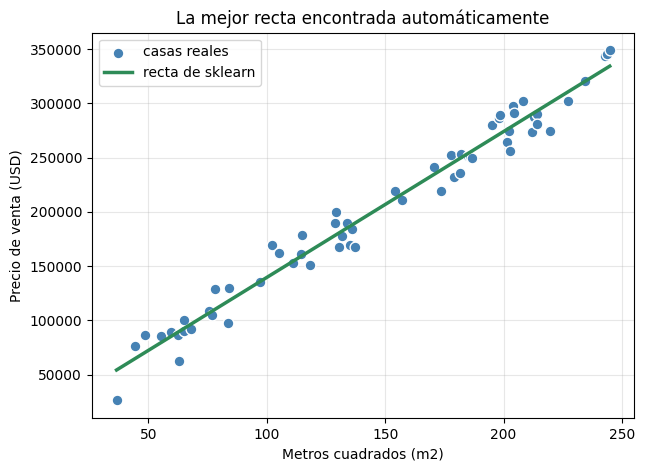

RMSE del modelo de sklearn: $13,453
(Comparalo con el RMSE más bajo que lograste vos a mano)


In [15]:
precio_pred_modelo = modelo.predict(m2_reshaped)
mse_modelo = error_cuadratico_medio(precio, precio_pred_modelo)
rmse_modelo = np.sqrt(mse_modelo)

plt.figure(figsize=(7, 5))
plt.scatter(m2, precio, color="steelblue", edgecolor="white", s=60, label="casas reales", zorder=2)

m2_linea = np.array([m2.min(), m2.max()])
plt.plot(
    m2_linea,
    w_encontrada * m2_linea + b_encontrada,
    color="seagreen",
    linewidth=2.5,
    label="recta de sklearn",
    zorder=3,
)

plt.xlabel("Metros cuadrados (m2)")
plt.ylabel("Precio de venta (USD)")
plt.title("La mejor recta encontrada automáticamente")
plt.legend(loc="upper left")
plt.grid(alpha=0.3)
plt.show()

print(f"RMSE del modelo de sklearn: ${rmse_modelo:,.0f}")
print("(Comparalo con el RMSE más bajo que lograste vos a mano)")

## 6. Usar el modelo para predecir

Ahora que tenemos entrenado el modelo, podemos usarlo para predecir el precio de una casa nueva que no está en nuestros datos, con solo saber sus m2.

In [ ]:
m2_nueva_casa = 120

precio_estimado = modelo.predict([[m2_nueva_casa]])[0]
print(f"Una casa de {m2_nueva_casa} m2 se estimaría en ${precio_estimado:,.0f}")